## Mesurer l’effet du capital humain sur la probabilité d’avoir un revenu élevé.

## ⚙️ Régression logistique & Elasticité & Analyse marginale

### ➡️ Librairies nécessaires

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
import statsmodels.api as sm

### ➡️ Dataset

In [3]:
data = pd.read_csv("Data/adult_S11.csv")

# Nettoyage simple
data = data.replace("?", np.nan).dropna()

# Encodage des variables catégorielles
cat_cols = ['workclass','education','marital-status','occupation',
            'relationship','race','gender','native-country','income']

for col in cat_cols:
    data[col] = LabelEncoder().fit_transform(data[col])

# Définition des variables
X = data[['age','education','educational-num','hours-per-week',
        'workclass','occupation','gender','race','capital-gain',
        'capital-loss','marital-status','relationship','native-country']]

y = data['income']  # 0 = <=50K, 1 = >50K

In [4]:
data.head()

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,2,226802,1,7,4,6,3,2,1,0,0,40,38,0
1,38,2,89814,11,9,2,4,0,4,1,0,0,50,38,0
2,28,1,336951,7,12,2,10,0,4,1,0,0,40,38,1
3,44,2,160323,15,10,2,6,0,2,1,7688,0,40,38,1
5,34,2,198693,0,6,4,7,1,4,1,0,0,30,38,0


### ➡️ Régression logistique

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)

y_pred = log_reg.predict(X_test)

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.95      0.89     10241
           1       0.71      0.41      0.52      3326

    accuracy                           0.82     13567
   macro avg       0.77      0.68      0.70     13567
weighted avg       0.80      0.82      0.80     13567

[[9690  551]
 [1958 1368]]


c:\Users\hp\.conda\Lib\site-packages\sklearn\linear_model\_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


### ➡️ Statsmodels pour effets marginaux

In [8]:
X_sm = sm.add_constant(X)
model = sm.Logit(y, X_sm).fit()
print(model.summary())

# Effets marginaux
marginal_effects = model.get_margeff().summary()
print(marginal_effects)

Optimization terminated successfully.
         Current function value: 0.391377
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:                 income   No. Observations:                45222
Model:                          Logit   Df Residuals:                    45208
Method:                           MLE   Df Model:                           13
Date:                Tue, 07 Jul 2026   Pseudo R-squ.:                  0.3011
Time:                        21:43:33   Log-Likelihood:                -17699.
converged:                       True   LL-Null:                       -25322.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const              -7.9072      0.162    -48.759      0.000      -8.225      -7.589
age           

### ➡️ Elasticité

In [9]:
params = model.params
means = X.mean()
p = model.predict(X_sm).mean()

elasticities = params[1:] * (means / (p * (1 - p)))
elasticities

age                 7.302687
education           1.012998
educational-num    18.173917
hours-per-week      6.329658
workclass          -1.512436
occupation         -0.036779
gender              3.261577
race                2.210012
capital-gain        1.870792
capital-loss        0.314172
marital-status     -3.043164
relationship       -1.081405
native-country     -0.096293
dtype: float64

### ➡️ Visualisation

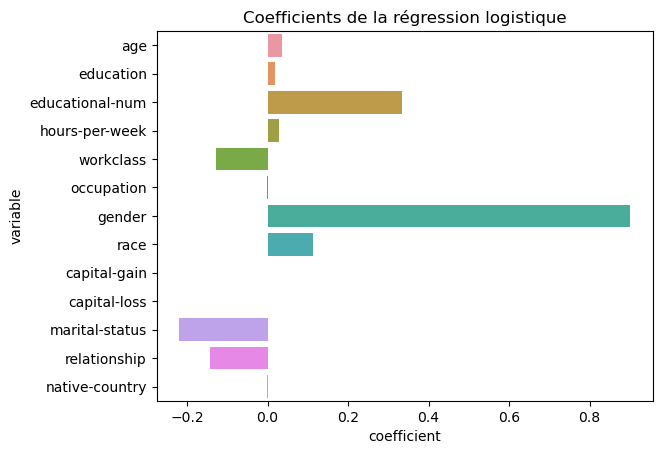

In [10]:
coef = pd.DataFrame({
    'variable': X.columns,
    'coefficient': model.params[1:]
})

sns.barplot(data=coef, x='coefficient', y='variable')
plt.title("Coefficients de la régression logistique")
plt.show()

### ➡️ Résumé

L’analyse montre que plusieurs dimensions du capital humain influencent fortement la probabilité d’obtenir un revenu élevé. L’âge, le niveau d’éducation, les heures travaillées et les gains en capital ressortent comme des facteurs déterminants. Les effets marginaux confirment que ces variables augmentent significativement la probabilité d’un revenu supérieur, tandis que des caractéristiques comme le statut marital ou le type de relation au foyer jouent plutôt un rôle négatif. Les élasticités renforcent ces résultats : l’éducation, l’expérience et le temps de travail sont les leviers les plus sensibles.
En résumé, le capital humain reste un moteur essentiel de la progression salariale, et ses composantes structurent fortement les écarts de revenu observés.